#데이터 불러오기

In [42]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# 데이터 불러오기
df = pd.read_csv("jobseekers_25.csv")

df.head()

,before_score,after_score
0,62,66
1,68,71
2,71,76
3,65,67
4,74,78


In [43]:
before_mean = df["before_score"].mean()
after_mean = df["after_score"].mean()

print(f"교육 전 평균: {before_mean:.2f}")
print(f"교육 후 평균: {after_mean:.2f}")
print(f"평균 변화량: {after_mean - before_mean:.2f}")

교육 전 평균: 68.76
교육 후 평균: 72.76
평균 변화량: 4.00


# 쌍체표본 인것으로 생각, 정규성 검증 시작

In [44]:
before =df["before_score"]
after = df["after_score"]

In [45]:
import pandas as pd

from scipy import stats

stats.shapiro(after - before) # Shapiro-Wilk 검정

#확인결과 pvalue 가 0.48로 정규성이 검증됨

ShapiroResult(statistic=np.float64(0.9632940103365952), pvalue=np.float64(0.4839002174433268))

# 쌍체표본 T검증

H0 = 전과 후의 모의 점수는 같다.  p value < 0.05
H1 = 전과 후의 모의 점수는 다르다.  p value >= 0.05

In [46]:
stats.ttest_rel(before, after)

# T검증 결과 p value가 0 이하였기에 강한 H1

TtestResult(statistic=np.float64(-13.587324409735148), pvalue=np.float64(9.163952098716969e-13), df=np.int64(24))

# 검증결과
이상황에서 전과 후의 점수가 동일하지 않다는것은 확인

# 수업이후 좋아졌는지 나빠졌는지를 before과 after을 이용하여 양과 음수로 확인

In [47]:
import numpy as np
np.mean(before) 
np.mean(after)

np.mean(before) - np.mean(after)

# 전후 차이 계산(개인별 점수 차이)
diff = after - before

# 점수 차이의 평균 계산(평균 점수 증가?량)
mean_diff = np.mean(diff)

# 점수 차이의 표준편차(증가?량의 표준편차)
std_diff = np.std(diff, ddof=1)

# 점수 차이의 표준오차(표본에서 구한 점수 차이(증가)량의 불확실성을 나타냄)
standard_error = std_diff / np.sqrt(len(diff))

# t-통계량 계산(점수 차이 (증가)량이 표준오차보다 몇 배 큰지를 나타냄)
t_statistic = mean_diff / standard_error
t_statistic
# 계산 결과 출력
print("===== Before / After 분석 결과 =====")
print(f"면접 코칭 전의 평균 점수     : {np.mean(before):.2f}")
print(f"면접 코칭 후의 평균 점수      : {np.mean(after):.2f}")
print(f"평균 점수 차이        : {mean_diff:.2f}")
print(f"점수 차이의 표준편차  : {std_diff:.2f}")
print(f"점수 차이의 표준오차  : {standard_error:.2f}")
print(f"t-통계량              : {t_statistic:.2f}")
print("====================================")

===== Before / After 분석 결과 =====
면접 코칭 전의 평균 점수     : 68.76
면접 코칭 후의 평균 점수      : 72.76
평균 점수 차이        : 4.00
점수 차이의 표준편차  : 1.47
점수 차이의 표준오차  : 0.29
t-통계량              : 13.59


# 이쯤에서 얼마나 점수가 올랐다는것까지 확인안료, 이후 이것을 표로 나타내서 얼마나 달라졌는지를 알아내려함

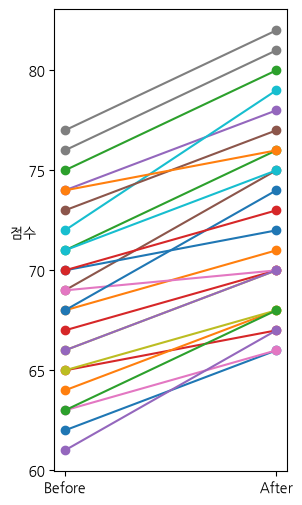

In [48]:
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = 'NanumGothic'

plt.figure(figsize=(3, 6))
for i in range(len(before)):
    plt.plot(["Before", "After"], [before[i], after[i]], marker="o")
    

plt.ylabel("점수",rotation=0)
plt.show()
